In [38]:
!pip install numpy
!pip install pandas
!pip install matplotlib
!pip install seaborn

In [84]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error, r2_score
from statsmodels.stats.diagnostic import normal_ad
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import shapiro
import statsmodels.api as sm
from sklearn.ensemble import RandomForestRegressor

In [86]:
cal = pd.read_csv('Cali-price.csv')

In [88]:
cal.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  int64  
 3   total_rooms         20640 non-null  int64  
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  int64  
 6   households          20640 non-null  int64  
 7   median_income       20640 non-null  float64
 8   ocean_proximity     20640 non-null  object 
 9   median_house_value  20640 non-null  int64  
dtypes: float64(4), int64(5), object(1)
memory usage: 1.6+ MB


In [90]:
cal.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,-119.569704,35.631861,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,2.003532,2.135952,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,-124.350000,32.540000,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,-121.800000,33.930000,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,-118.490000,34.260000,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,-118.010000,37.710000,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,-114.310000,41.950000,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


In [92]:
cal.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,ocean_proximity,median_house_value
0,-122.23,37.88,41,880,129.0,322,126,8.3252,NEAR BAY,452600
1,-122.22,37.86,21,7099,1106.0,2401,1138,8.3014,NEAR BAY,358500
2,-122.24,37.85,52,1467,190.0,496,177,7.2574,NEAR BAY,352100
3,-122.25,37.85,52,1274,235.0,558,219,5.6431,NEAR BAY,341300
4,-122.25,37.85,52,1627,280.0,565,259,3.8462,NEAR BAY,342200


In [94]:
cal.shape

(20640, 10)

In [58]:
cal.isnull().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
ocean_proximity         0
median_house_value      0
dtype: int64

In [118]:
# we can notice that we have 207 missing values in total_bedrooms 
categorical_cols = cal.select_dtypes(include=['object']).columns
numeric_cols = cal.select_dtypes(include=['number']).columns

In [120]:
cal['total_bedrooms'] = cal['total_bedrooms'].fillna(cal['total_bedrooms'].mode()[0])

In [122]:
cal.isnull().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
ocean_proximity       0
median_house_value    0
dtype: int64

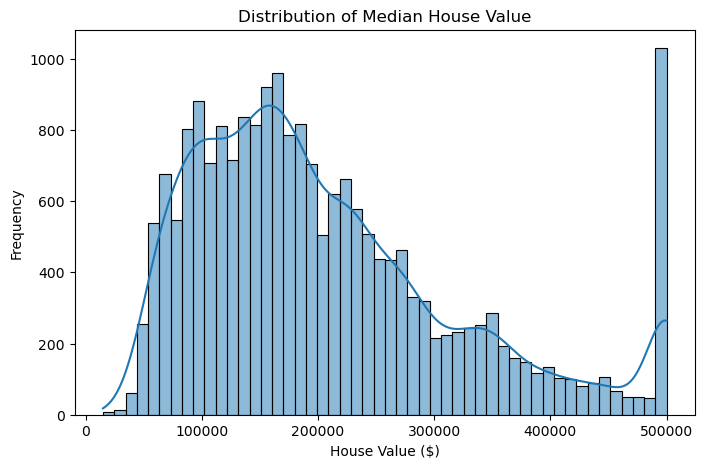

In [124]:
plt.figure(figsize=(8, 5))
sns.histplot(Cal['median_house_value'], bins=50, kde=True)
plt.title("Distribution of Median House Value")
plt.xlabel("House Value ($)")
plt.ylabel("Frequency")
plt.show()

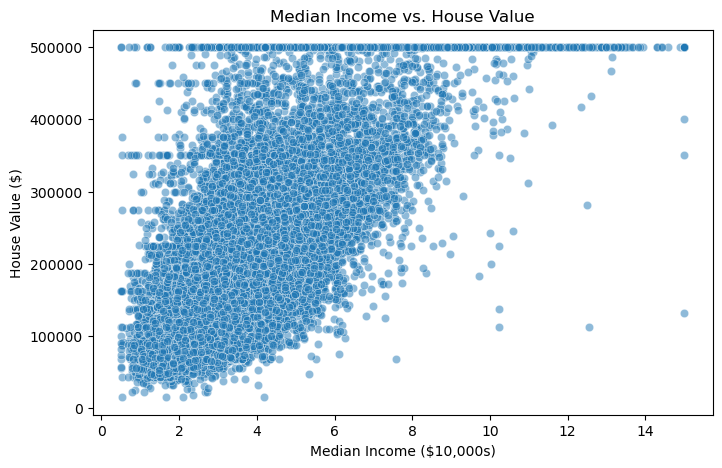

In [126]:
plt.figure(figsize=(8, 5))
sns.scatterplot(x=Cal['median_income'], y=Cal['median_house_value'], alpha=0.5)
plt.title("Median Income vs. House Value")
plt.xlabel("Median Income ($10,000s)")
plt.ylabel("House Value ($)")
plt.show()

In [142]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

x = Cal.drop(columns=['median_house_value'])  # Features
y = Cal['median_house_value']  # Target variable

# Identify categorical and numerical columns
categorical_features = x.select_dtypes(include=['object']).columns
numerical_features = x.select_dtypes(include=['int64', 'float64']).columns


# Split into train (80%) and test (20%) sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# Initialize StandardScaler
scaler = StandardScaler()

# Select only numerical columns for scaling
numerical_features = x_train.columns[:8]

# Apply scaling to numerical features
x_train_scaled = scaler.fit_transform(x_train[numerical_features])
x_test_scaled = scaler.transform(x_test[numerical_features])

# Convert back to DataFrame and ensure proper float dtype
x_train[numerical_features] = pd.DataFrame(x_train_scaled, columns=numerical_features, index=x_train.index).astype(np.float64)
x_test[numerical_features] = pd.DataFrame(x_test_scaled, columns=numerical_features, index=x_test.index).astype(np.float64)

In [144]:
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((16512, 9), (4128, 9), (16512,), (4128,))

In [146]:
# let's now implement 5 regression algorithms into the data 
#Linear Regression , Polynomial Regression ,Ridge Regression , Lasso Regression and Random Forest Regression

In [171]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, PolynomialFeatures  
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import make_pipeline  



# Define features (X) and target (Y)
X = Cal.drop(columns=['median_house_value'])  # Features
y = Cal['median_house_value']  # Target variable

# 🔹 Identify categorical and numerical columns
categorical_features = x.select_dtypes(include=['object']).columns
numerical_features = x.select_dtypes(include=['int64', 'float64']).columns

# 🔹 Convert categorical variables into numerical (One-Hot Encoding)
x = pd.get_dummies(x, columns=categorical_features, drop_first=True)

# 🔹 Standardize numerical features
scaler = StandardScaler()
x[numerical_features] = scaler.fit_transform(x[numerical_features])

# 🔹 Split data into training (80%) and testing (20%) sets
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

# 🔹 Define regression models
models = {
    "Linear Regression": LinearRegression(),
    "Polynomial Regression (Degree=2)": make_pipeline(PolynomialFeatures(degree=2), LinearRegression()),  
    "Ridge Regression": Ridge(alpha=1.0),
    "Lasso Regression": Lasso(alpha=0.1),
    "Random Forest Regression": RandomForestRegressor(n_estimators=100, random_state=42)
}

# 🔹 Train and evaluate models
results = []
for name, model in models.items():
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    results.append([name, mae, rmse, r2])

# 🔹 Convert results into a DataFrame
results_df = pd.DataFrame(results, columns=["Model", "MAE", "RMSE", "R² Score"])

# 🔹 Display results
from IPython.display import display
display(results_df)

,Model,MAE,RMSE,R² Score
0,Linear Regression,50670.738241,70060.521845,0.625424
1,Polynomial Regression (Degree=2),46390.136064,67151.354225,0.655886
2,Ridge Regression,50678.358594,70068.808935,0.625335
3,Lasso Regression,50670.833409,70060.605619,0.625423
4,Random Forest Regression,31642.757536,49034.574829,0.816516


In [173]:
# we can see the result of each regression algorithms 